# Calcolo della f0 su tutto il dataset

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from lib.readwav import readwav
import ipywidgets as widgets
import json
import emcee
from scipy.special import logsumexp
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.lines as mlines
import csv


In [9]:
%matplotlib widget
plt.close('all')

In [ ]:
def get_f0_first_peak(peak_freqs):
    return peak_freqs[0] if len(peak_freqs) > 0 else None

def f0_MCD(peak_freqs, step=0.1, missing_penalty=0.1, update_threshold=0.95):
    
    # min e max considerati
    min_candidate = np.min(peak_freqs) / 2
    max_candidate = np.min(peak_freqs) * 2
    
    # griglia di punti su cui valutare mcd. Parto dall'alto perchè voglio avvantaggiare i multipli piuttosto che i sottomultipli
    candidates = np.arange(max_candidate, min_candidate, -step)

    # inizializza variabili per tenere traccia del miglior candidato
    lowest_residual = float("inf")
    best_f0 = None

    for f0 in candidates:

        # calcola i rapporti tra le frequenze dei picchi e il candidato f0 e arrotonda ai numeri interi più vicini
        ratios = peak_freqs / f0
        integer_ratios = np.round(ratios)
        
        # se uno dei rapporti arrotondati è zero, significa che il candidato f0 è troppo grande e non può essere una fondamentale valida, quindi salto questo candidato
        if np.any(integer_ratios == 0):
            continue

        # calcola i residui tra i rapporti reali e quelli interi e somma i residui totali
        residuals = np.abs(ratios - integer_ratios)
        tot_residual = np.sum(residuals)

        # trova il numero di armoniche mancanti e applica una penalità al residuo totale
        missing_harmonics = np.max(integer_ratios) - len(peak_freqs)
        tot_residual += missing_harmonics * missing_penalty

        # se miglioriamo a sufficienza la stima, aggiorniamo il miglior candidato e il residuo più basso
        if tot_residual < (lowest_residual * update_threshold):
            lowest_residual = tot_residual
            best_f0 = f0
    
    return best_f0


In [11]:
def get_limiti_prior(observed_freqs):

    f_min = 66
    f_max = 1568

    q_min = 0.1
    q_max = 1

    log_sigma_min = np.log(0.1)
    log_sigma_max = np.log(100)

    log_uniform = -np.log(f_max - f_min)

    return f_min, f_max, log_sigma_min, log_sigma_max, log_uniform, q_min, q_max

# prior uniforme con 1/ns
def compute_uniform_prior(ns):
    log_prior = -np.log(ns)
    return log_prior

In [12]:
def get_f0_bayesian_map(peak_freqs, peak_mags):

    f_min, f_max, log_sigma_min, log_sigma_max, log_uniform, q_min, q_max = get_limiti_prior(peak_freqs)

    ns = len(peak_freqs)  # Consideriamo tante armoniche quanti sono i picchi
    P_n_log = compute_uniform_prior(ns)  # Sostituisci con il prior uniforme
    U_log = log_uniform # Probabilità uniforme del rumore
    ns_indices = np.arange(1, ns + 1)

    def log_prob(theta):

        f0, log_sigma, q = theta
        sigma = np.exp(log_sigma)

        if not (f_min < f0 < f_max and log_sigma_min < log_sigma < log_sigma_max and q_min < q < q_max):
            return -1e15

        total_log_likelihood = 0.0

        for fk in peak_freqs:

            log_gaussians = -0.5 * ((fk - ns_indices * f0) / sigma)**2 - log_sigma - 0.5 * np.log(2 * np.pi)
            
            log_p_harmonics = logsumexp(log_gaussians + P_n_log)

            log_p_total = np.logaddexp(np.log(q) + log_p_harmonics, np.log(1 - q) + U_log)
            
            total_log_likelihood += log_p_total

        return total_log_likelihood

    f_start = float(peak_freqs[0])  

    sigma_start = np.log(0.1*f_start)  

    q_start = 0.8

    x0 = [f_start, sigma_start, q_start]

    res = sp.optimize.minimize(
        lambda t: -log_prob(t),
        x0=x0,
        method='L-BFGS-B',
        bounds=[
            (f_min, f_max),
            (log_sigma_min, log_sigma_max),
            (q_min, q_max)
        ],
        options={'maxiter': 300}
    )

    f0_map, log_sigma_map, q_map = res.x
    q_map = float(np.clip(q_map, q_min, q_max))
    print(f"MAP Singolo -> F0: {f0_map:.2f}Hz, Sigma: {np.exp(log_sigma_map):.5f}Hz, q: {q_map:.8f}")

    return f0_map, q_map

In [13]:
base_dir = "dati_processati"
peak_file = "spettri_peaks.json"

filepath = os.path.join(base_dir, peak_file)

with open(filepath, 'r') as f:
    peaks_dict = json.load(f)


In [14]:

f0_results = {}
bayesian_q_results = {}
avg_error_results = {}
for sample, data in peaks_dict.items():
    print(f"Processing {sample}...")
    freqs = np.array(data["peaks"]['frequencies'])
    mags = np.array(data["peaks"]['magnitudes'])

    bayesian_map_result = get_f0_bayesian_map(freqs, mags)
    if bayesian_map_result is None:
        bayesian_map_f0 = None
        bayesian_map_q = None
    else:
        bayesian_map_f0, bayesian_map_q = bayesian_map_result

    f0_results[sample] = {
        'first_peak': get_f0_first_peak(freqs),
        'mcd': f0_MCD(freqs),
        'bayesian_map': bayesian_map_f0
    }
    bayesian_q_results[sample] = bayesian_map_q
    
    avg_error_results[sample] = {}
    
    # Iteriamo su tutti i risultati trovati per calcolare l'errore senza ripetere codice
    for method_name, f0_candidate in f0_results[sample].items():
        if f0_candidate is not None and f0_candidate > 0:
            # Calcolo errore relativo: |(f / f0) - round(f / f0)|
            relative_errors = np.abs((freqs / f0_candidate) - np.round(freqs / f0_candidate))

            avg_error_results[sample][method_name] = np.mean(relative_errors) 
        else:
            avg_error_results[sample][method_name] = None

Processing Nota_1...
MAP Singolo -> F0: 1563.26Hz, Sigma: 0.58997Hz, q: 0.99999998
Processing Nota_2...
MAP Singolo -> F0: 1481.89Hz, Sigma: 0.10427Hz, q: 0.10364583
Processing Nota_3...
MAP Singolo -> F0: 330.67Hz, Sigma: 0.52786Hz, q: 0.79834139
Processing Nota_4...
MAP Singolo -> F0: 184.82Hz, Sigma: 38.03211Hz, q: 0.10000001
Processing Nota_5...
MAP Singolo -> F0: 226.17Hz, Sigma: 0.65915Hz, q: 0.10000001
Processing Nota_6...
MAP Singolo -> F0: 467.21Hz, Sigma: 0.10152Hz, q: 0.99950870
Processing Nota_7...
MAP Singolo -> F0: 175.08Hz, Sigma: 0.10023Hz, q: 0.99994432
Processing Nota_8...
MAP Singolo -> F0: 783.10Hz, Sigma: 0.51333Hz, q: 0.91980271
Processing Nota_9...
MAP Singolo -> F0: 155.91Hz, Sigma: 0.10000Hz, q: 0.93318227
Processing Nota_10...
MAP Singolo -> F0: 260.25Hz, Sigma: 0.46892Hz, q: 0.10000000
Processing Nota_11...
MAP Singolo -> F0: 1399.80Hz, Sigma: 0.11284Hz, q: 0.11223932
Processing Nota_12...
MAP Singolo -> F0: 1178.65Hz, Sigma: 0.46343Hz, q: 0.99999998
Processi

In [15]:
output_file = os.path.join(base_dir, "f0_results_all.csv")

with open(output_file, 'w', newline='') as f_out:
    writer = csv.writer(f_out)
    writer.writerow(['Note', 'First Peak', 'MCD', 'Bayesian MAP'])
    
    for sample in sorted(f0_results.keys(), key=lambda x: int(x.split('_')[1])):

        note_num = sample.split('_')[1]
        
        results = f0_results[sample]
        writer.writerow([
            note_num,
            results['first_peak'],
            results['mcd'],
            results['bayesian_map']
        ])

print(f"Risultati salvati in {output_file}")

Risultati salvati in dati_processati/f0_results_all.csv


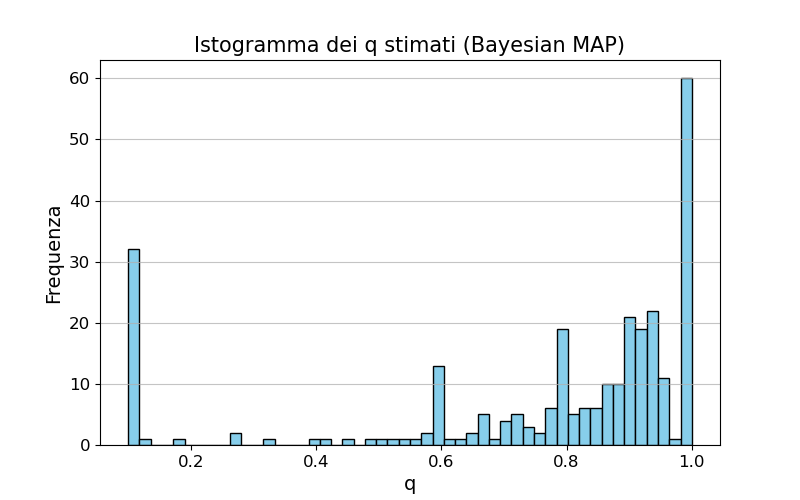

In [16]:
plt.rcParams.update({
    'font.size': 12,          # Dimensione base per tutto
    'axes.titlesize': 15,     # Titolo del grafico
    'axes.labelsize': 14,     # Etichette X e Y
    'xtick.labelsize': 12,    # Numeretti asse X
    'ytick.labelsize': 12,    # Numeretti asse Y
    'legend.fontsize': 12
})

# istogramma delle q_map stimate con il metodo bayesiano
bayesian_qs = [q for q in bayesian_q_results.values() if q is not None]
plt.figure(figsize=(8, 5))
plt.hist(bayesian_qs, bins=50, color='skyblue', edgecolor='black')
plt.title('Istogramma dei q stimati (Bayesian MAP)')
plt.xlabel('q')
plt.ylabel('Frequenza')
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.savefig(os.path.join(base_dir, "bayesian_q_histogram.png"))


In [17]:
for sample, results in f0_results.items():
    print(f"{sample}:")
    for method, f0 in results.items():
        print(f"  {method}: {f0}")

Nota_1:
  first_peak: 1562.6370790865697
  mcd: 2918.0741581733278
  bayesian_map: 1563.2614400096113
Nota_2:
  first_peak: 1481.8912352831248
  mcd: 2735.882470566457
  bayesian_map: 1481.8909221056742
Nota_3:
  first_peak: 329.8213467704993
  mcd: 566.7426935409775
  bayesian_map: 330.6670939845324
Nota_4:
  first_peak: 173.30582447230597
  mcd: 280.1116489445968
  bayesian_map: 184.8234774378331
Nota_5:
  first_peak: 220.73956801990275
  mcd: 337.1791360397818
  bayesian_map: 226.165186131974
Nota_6:
  first_peak: 467.2118809894135
  mcd: 764.6237619787884
  bayesian_map: 467.2118013221719
Nota_7:
  first_peak: 175.08024511234316
  mcd: 334.96049022468287
  bayesian_map: 175.0797318414815
Nota_8:
  first_peak: 783.6443916737784
  mcd: 1515.7887833476036
  bayesian_map: 783.0999873750412
Nota_9:
  first_peak: 155.90613814132308
  mcd: 297.5122762826429
  bayesian_map: 155.90613786059856
Nota_10:
  first_peak: 233.05355865858706
  mcd: 394.90711731715794
  bayesian_map: 260.2482482909

In [18]:
note_freqs = {}
for octave in range(1, 7):  # 1..8
    for i, note in enumerate(["DO", "DO#", "RE", "RE#", "MI", "FA", "FA#", "SOL", "SOL#", "LA", "LA#", "SI"]):
        freq = 16.35 * (2 ** octave) * (2 ** (i / 12))
        note_freqs[f"{note}{octave}"] = freq

print("Frequenze delle note:")
for note, freq in sorted(note_freqs.items()):
    print(f"  {note}: {freq:.2f} Hz")

Frequenze delle note:
  DO#1: 34.64 Hz
  DO#2: 69.29 Hz
  DO#3: 138.58 Hz
  DO#4: 277.16 Hz
  DO#5: 554.31 Hz
  DO#6: 1108.62 Hz
  DO1: 32.70 Hz
  DO2: 65.40 Hz
  DO3: 130.80 Hz
  DO4: 261.60 Hz
  DO5: 523.20 Hz
  DO6: 1046.40 Hz
  FA#1: 46.24 Hz
  FA#2: 92.49 Hz
  FA#3: 184.98 Hz
  FA#4: 369.96 Hz
  FA#5: 739.92 Hz
  FA#6: 1479.83 Hz
  FA1: 43.65 Hz
  FA2: 87.30 Hz
  FA3: 174.60 Hz
  FA4: 349.19 Hz
  FA5: 698.39 Hz
  FA6: 1396.78 Hz
  LA#1: 58.26 Hz
  LA#2: 116.53 Hz
  LA#3: 233.06 Hz
  LA#4: 466.12 Hz
  LA#5: 932.24 Hz
  LA#6: 1864.47 Hz
  LA1: 54.99 Hz
  LA2: 109.99 Hz
  LA3: 219.98 Hz
  LA4: 439.96 Hz
  LA5: 879.91 Hz
  LA6: 1759.83 Hz
  MI1: 41.20 Hz
  MI2: 82.40 Hz
  MI3: 164.80 Hz
  MI4: 329.60 Hz
  MI5: 659.19 Hz
  MI6: 1318.38 Hz
  RE#1: 38.89 Hz
  RE#2: 77.77 Hz
  RE#3: 155.55 Hz
  RE#4: 311.10 Hz
  RE#5: 622.19 Hz
  RE#6: 1244.39 Hz
  RE1: 36.70 Hz
  RE2: 73.41 Hz
  RE3: 146.82 Hz
  RE4: 293.64 Hz
  RE5: 587.27 Hz
  RE6: 1174.54 Hz
  SI1: 61.73 Hz
  SI2: 123.46 Hz
  SI3: 246

In [19]:
types = [
    "first_peak",
    "mcd",
    "bayesian_map"
]

# separa i risultati per metodo e rimiovi i None
method_results = {method: [] for method in types}
for sample, results in f0_results.items():
    for method in types:
        method_results[method].append(results[method])

# rimuovi i None values
for method in types:
    method_results[method] = [freq for freq in method_results[method] if freq is not None]


# binning dei risultati nelle note più vicine
def find_closest_note(freq, note_freqs):
    closest_note = None
    min_diff = float('inf')
    for note, note_freq in note_freqs.items():
        diff = abs(freq - note_freq)
        if diff < min_diff:
            min_diff = diff
            closest_note = note
    return closest_note

binned_results = {method: [] for method in types}
for method in types:
    for freq in method_results[method]:
        if freq is not None:
            closest_note = find_closest_note(freq, note_freqs)
            binned_results[method].append(closest_note)
        else:
            binned_results[method].append(None)



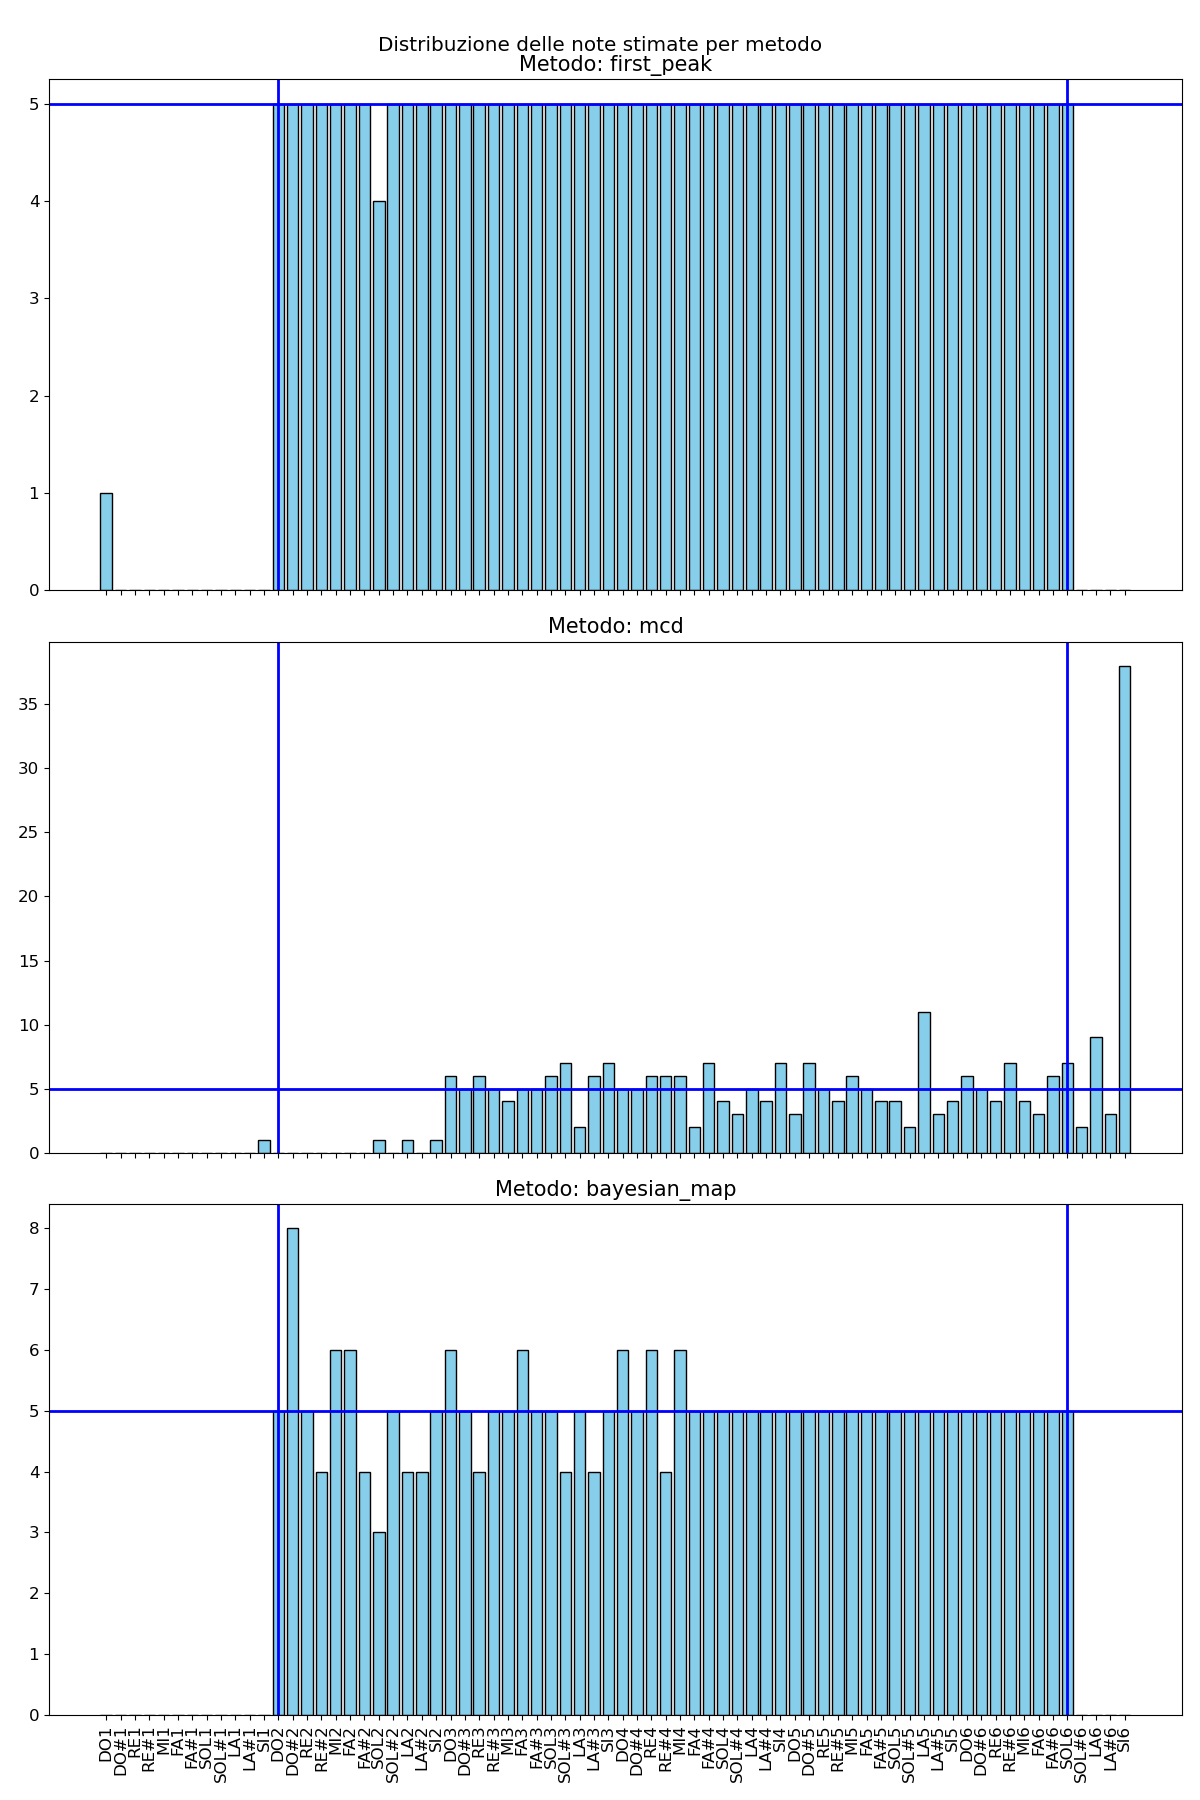

In [20]:
ordered_notes = list(note_freqs.keys())
fig, axs = plt.subplots(len(types), 1, figsize=(12, 18), sharex=True)

fig.suptitle("Distribuzione delle note stimate per metodo")

for i, method in enumerate(types):
    counts = [binned_results[method].count(note) for note in ordered_notes]
    axs[i].bar(np.arange(len(ordered_notes)), counts, width=0.8, color='skyblue', edgecolor='black')
    axs[i].set_title(f"Metodo: {method}")
    axs[i].set_xticks(np.arange(len(ordered_notes)))
    axs[i].set_xticklabels(ordered_notes, rotation=90)
    axs[i].axhline(5, color='blue', linewidth=2)
    if "DO2" in ordered_notes:
        axs[i].axvline(ordered_notes.index("DO2"), color='blue', linewidth=2)
    if "SOL6" in ordered_notes:
        axs[i].axvline(ordered_notes.index("SOL6"), color='blue', linewidth=2)


plt.tight_layout()
plt.show()

plt.savefig(os.path.join(base_dir, "note_distribution_by_method.png"))